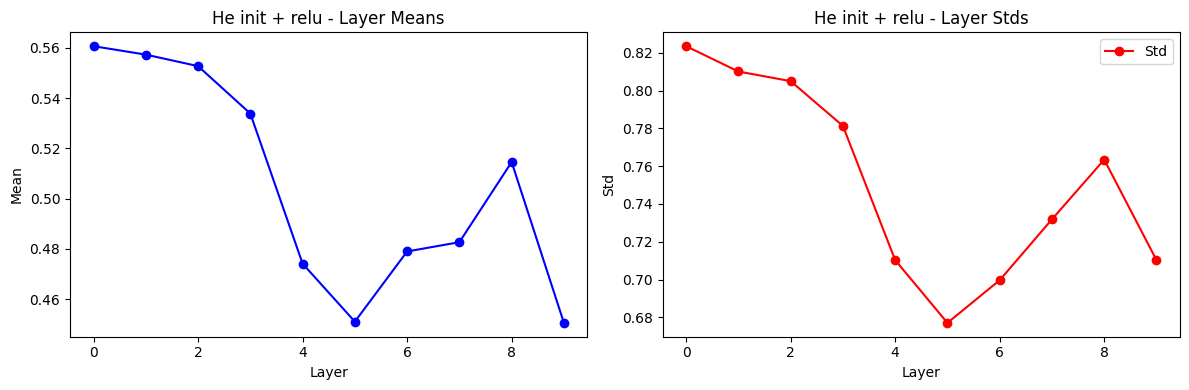

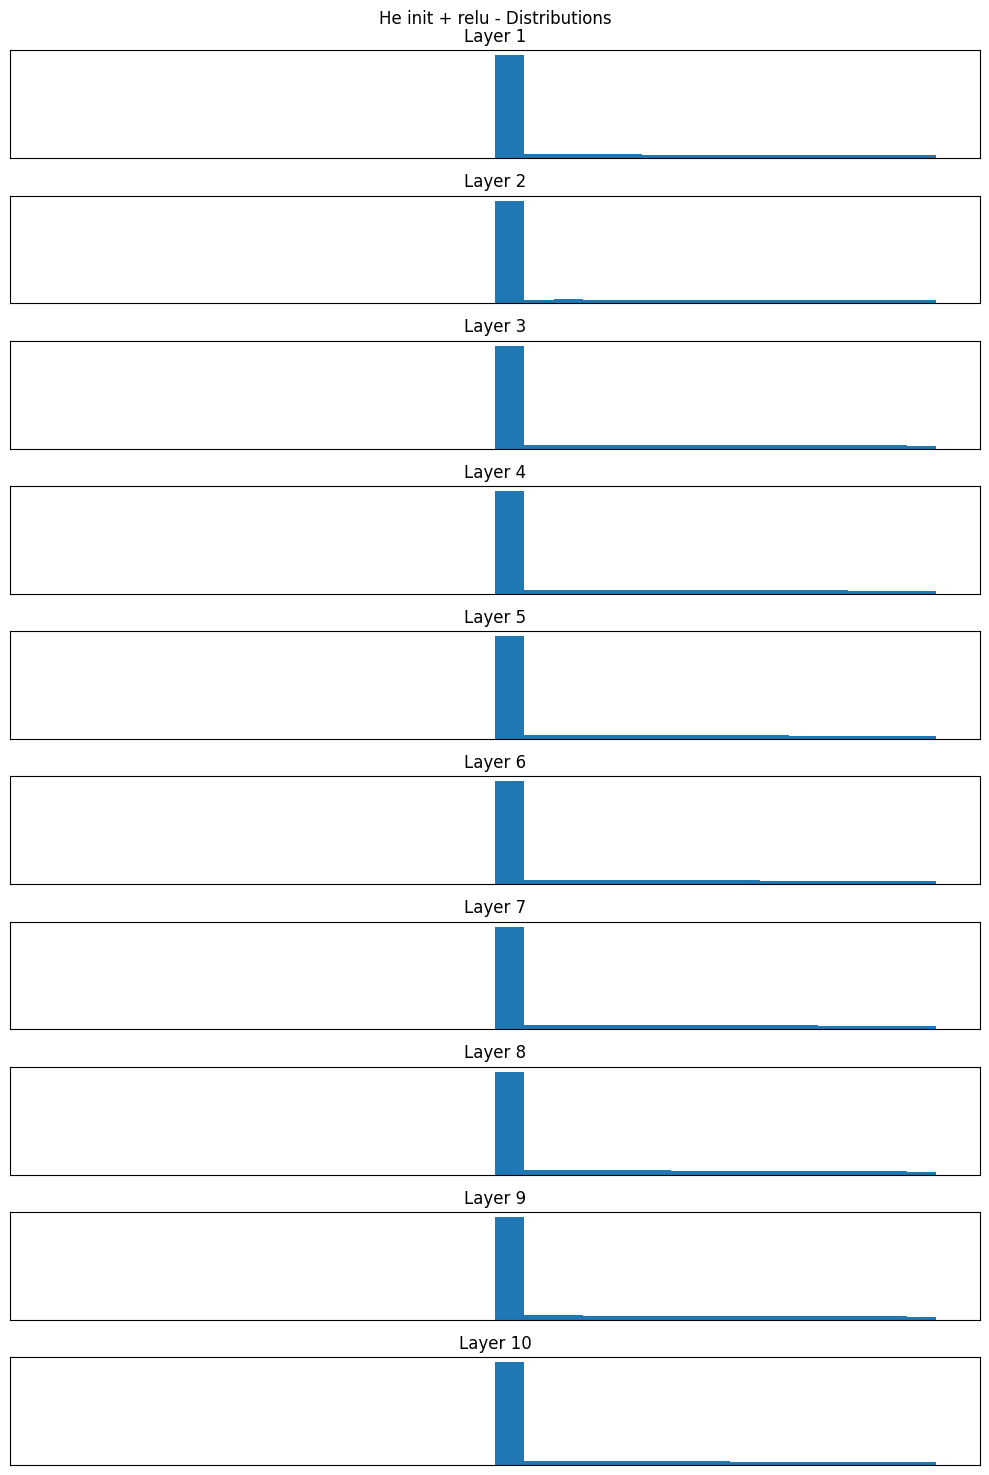

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Constant parameters
N, D = 1000, 100  # Number of samples and input dimension
hidden_layer_sizes = [500] * 10  # 10 hidden layers with 500 neurons each
nonlinearities = ['relu'] * len(hidden_layer_sizes)  # ReLU activation function for all layers

# Activation functions
act_funcs = {
    'relu': lambda x: np.maximum(0, x),  # ReLU function
    'tanh': lambda x: np.tanh(x)  # Tanh function
}

# Weight initialization function (He Initialization)
def he_init(fan_in, fan_out):
    return np.random.randn(fan_in, fan_out) * np.sqrt(2. / fan_in)  # He initialization (scaled by sqrt(2/fan_in))

# Experiment function
def run_experiment(activation):
    np.random.seed(0)  # Set random seed for reproducibility
    X = np.random.randn(N, D)  # Input data (randomly generated)
    Hs = {}  # Dictionary to store activations of each layer

    # Forward pass through each layer
    for i in range(len(hidden_layer_sizes)):
        X = X if i == 0 else Hs[i-1]  # For the first layer, use the input data, for subsequent layers, use the previous layer's output
        fan_in = X.shape[1]  # Input dimension (number of neurons in the previous layer)
        fan_out = hidden_layer_sizes[i]  # Output dimension (number of neurons in the current layer)
        W = he_init(fan_in, fan_out)  # Initialize weights using He initialization
        H = X @ W  # Perform matrix multiplication with the weights
        H = act_funcs[activation](H)  # Apply the activation function
        Hs[i] = H  # Store the output of this layer

    # Calculate means and standard deviations of activations
    layer_means = [np.mean(H) for H in Hs.values()]  # Mean activation per layer
    layer_stds = [np.std(H) for H in Hs.values()]  # Standard deviation of activations per layer

    # Plot mean and std
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(Hs.keys(), layer_means, 'ob-', label='Mean')
    plt.title(f'He init + {activation} - Layer Means')
    plt.xlabel('Layer')
    plt.ylabel('Mean')
    
    plt.subplot(1, 2, 2)
    plt.plot(Hs.keys(), layer_stds, 'or-', label='Std')
    plt.title(f'He init + {activation} - Layer Stds')
    plt.xlabel('Layer')
    plt.ylabel('Std')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Histograms: Distribution of activations across layers
    plt.figure(figsize=(10, 15))
    for i, H in Hs.items():
        plt.subplot(len(Hs), 1, i + 1)
        plt.hist(H.ravel(), bins=30, range=(-1, 1))  # Plot histogram of activations
        plt.title(f'Layer {i+1}')
        plt.xticks([])  # Remove x-axis labels
        plt.yticks([])  # Remove y-axis labels
    plt.suptitle(f'He init + {activation} - Distributions')
    plt.tight_layout()
    plt.show()

# -------------------
# Run the experiment
# -------------------
run_experiment('relu')  # Run the experiment with ReLU activation function
